<a href="https://colab.research.google.com/github/Yasaswi1357/Drone_Detection_YOLO/blob/main/End_Sem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi
!pip install ultralytics albumentations kaggle Pillow matplotlib PyYAML

Mon Apr 13 13:05:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ─────────────────────────────────────────────
# 2. Download Datasets (FIXED VERSION)
# ─────────────────────────────────────────────

# Drone dataset (same as before)
!kaggle datasets download -d muki2003/yolo-drone-detection-dataset --force
!unzip -q yolo-drone-detection-dataset.zip -d /content/drone_dataset_raw

# Install FiftyOne (for COCO download)
!pip install -q fiftyone

# Download COCO dataset (only bird + airplane)
import fiftyone.zoo as foz

dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="train",
    label_types=["detections"],
    classes=["bird", "airplane"],
    max_samples=1500   # ensures >200 per class
)

Dataset URL: https://www.kaggle.com/datasets/muki2003/yolo-drone-detection-dataset
License(s): other
100% 359M/359M [00:02<00:00, 146MB/s]

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/coco-2017/train' if necessary


INFO:fiftyone.utils.coco:Downloading annotations to '/root/fiftyone/coco-2017/tmp-download/annotations_trainval2017.zip'


 100% |██████|    1.9Gb/1.9Gb [4.8s elapsed, 0s remaining, 457.5Mb/s]       


...

INFO:fiftyone.zoo.datasets:Loading 'coco-2017' split 'train'


 100% |███████████████| 1500/1500 [6.3s elapsed, 0s remaining, 264.7 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 1500/1500 [6.3s elapsed, 0s remaining, 264.7 samples/s]      


Dataset 'coco-2017-train-1500' created


INFO:fiftyone.zoo.datasets:Dataset 'coco-2017-train-1500' created


In [ ]:
# ─────────────────────────────────────────────
# 3. Build Unified Dataset (drone=0, bird=1, airplane=2)
# ─────────────────────────────────────────────

import os, shutil, random
from pathlib import Path

DATASET_ROOT = Path("/content/unified_dataset")

# Create folders
for split in ["train", "valid"]:
    (DATASET_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
    (DATASET_ROOT / split / "labels").mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────
# 1. DRONE DATA (class 0) — SAME AS BEFORE
# ─────────────────────────────────────────────
def copy_drone_split(src_img_dir, src_lbl_dir, dst_split, class_id=0):
    src_imgs = list(Path(src_img_dir).glob("*.*"))
    for img_path in src_imgs:
        lbl_path = Path(src_lbl_dir) / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue

        shutil.copy(img_path, DATASET_ROOT / dst_split / "images" / img_path.name)

        lines = lbl_path.read_text().strip().splitlines()
        new_lines = []
        for line in lines:
            parts = line.split()
            parts[0] = str(class_id)
            new_lines.append(" ".join(parts))

        (DATASET_ROOT / dst_split / "labels" / lbl_path.name).write_text("\n".join(new_lines))


copy_drone_split(
    "/content/drone_dataset_raw/drone_dataset/train/images",
    "/content/drone_dataset_raw/drone_dataset/train/labels",
    "train",
    class_id=0
)

copy_drone_split(
    "/content/drone_dataset_raw/drone_dataset/valid/images",
    "/content/drone_dataset_raw/drone_dataset/valid/labels",
    "valid",
    class_id=0
)


# ─────────────────────────────────────────────
# 2. COCO → YOLO (bird=1, airplane=2) — EXACT 80/20 SPLIT
# ─────────────────────────────────────────────
class_map = {
    "bird": 1,
    "airplane": 2
}

coco_samples = []
count = {1: 0, 2: 0}

# Step A: Extract all valid samples and format their labels first
for sample in dataset:
    img_path = sample.filepath
    detections = sample.ground_truth.detections
    new_lines = []

    for det in detections:
        if det.label in class_map:
            cls = class_map[det.label]
            x, y, w, h = det.bounding_box  # normalized
            x_center = x + w / 2
            y_center = y + h / 2
            new_lines.append(f"{cls} {x_center} {y_center} {w} {h}")
            count[cls] += 1 # count tracking

    if new_lines:
        coco_samples.append((img_path, new_lines))

print("Final class distribution (COCO):", count)

# Step B: Shuffle and split precisely at 80%
random.shuffle(coco_samples)
coco_split_idx = int(len(coco_samples) * 0.8)

coco_train = coco_samples[:coco_split_idx]
coco_valid = coco_samples[coco_split_idx:]

def process_coco_split(sample_list, split):
    for img_path, lines in sample_list:
        new_name = Path(img_path).name
        shutil.copy(img_path, DATASET_ROOT / split / "images" / new_name)
        (DATASET_ROOT / split / "labels" / new_name.replace(".jpg", ".txt")).write_text("\n".join(lines))

process_coco_split(coco_train, "train")
process_coco_split(coco_valid, "valid")

Final class distribution (COCO): {1: 2723, 2: 1192}


In [ ]:

# ─────────────────────────────────────────────
# 4. Data Augmentation for Edge Cases
#    (low-light, blur, low-res simulation)
#    Applied ONLY to training images
# ─────────────────────────────────────────────
import cv2
import numpy as np
from PIL import Image, ImageFilter
import albumentations as A

# Albumentations pipeline — covers all end-sem requirements
augmentation_pipeline = A.Compose([

    # ── Low-light / night simulation ─────────────────────────────────────────
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=(-0.5, -0.2),
                                   contrast_limit=(-0.3, 0.0), p=1.0),   # darken
        A.RandomGamma(gamma_limit=(30, 70), p=1.0),                       # extreme gamma
    ], p=0.3),

    # ── Blur / low-resolution simulation ─────────────────────────────────────
    A.OneOf([
        A.MotionBlur(blur_limit=9, p=1.0),          # drone in motion
        A.GaussianBlur(blur_limit=(3, 9), p=1.0),   # camera shake
        A.Downscale(scale_min=0.25, scale_max=0.5,  # low-res sensor
                    interpolation=cv2.INTER_LINEAR, p=1.0),
        A.ImageCompression(quality_lower=10, quality_upper=40, p=1.0),  # JPEG artefacts
    ], p=0.4),

    # ── Standard augmentations ────────────────────────────────────────────────
    A.HorizontalFlip(p=0.5),
    A.RandomSizedBBoxSafeCrop(height=640, width=640, erosion_rate=0.0, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20,
                         val_shift_limit=20, p=0.3),
    A.CLAHE(clip_limit=4.0, p=0.2),                 # contrast boost (helps night)
    A.GaussNoise(var_limit=(10, 50), p=0.2),        # sensor noise

], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'],
                             min_visibility=0.2))


def augment_and_save(img_dir, lbl_dir, copies=2):
    """
    For each image in img_dir, generate `copies` augmented versions
    and save them back to the same directories.
    """
    img_paths = list(Path(img_dir).glob("*.*"))
    saved = 0
    for img_path in img_paths:
        lbl_path = Path(lbl_dir) / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue

        image = cv2.imread(str(img_path))
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]

        # Parse YOLO labels
        lines = lbl_path.read_text().strip().splitlines()
        bboxes, class_labels = [], []
        for line in lines:
            parts = line.split()
            class_labels.append(int(parts[0]))
            bboxes.append([float(x) for x in parts[1:]])

        for i in range(copies):
            try:
                result = augmentation_pipeline(
                    image=image, bboxes=bboxes, class_labels=class_labels)
                aug_img  = result["image"]
                aug_bbs  = result["bboxes"]
                aug_cls  = result["class_labels"]
            except Exception:
                continue

            if not aug_bbs:
                continue

            # Save augmented image
            aug_name = f"{img_path.stem}_aug{i}{img_path.suffix}"
            aug_img_path = Path(img_dir) / aug_name
            cv2.imwrite(str(aug_img_path),
                        cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

            # Save augmented label
            new_lines = []
            for cls, bb in zip(aug_cls, aug_bbs):
                new_lines.append(f"{cls} {' '.join(f'{v:.6f}' for v in bb)}")
            (Path(lbl_dir) / (aug_name.replace(img_path.suffix, "") + ".txt")
             ).write_text("\n".join(new_lines))
            saved += 1

    print(f"  → {saved} augmented images saved in {img_dir}")


print("Augmenting training set (this takes a few minutes)…")
augment_and_save(DATASET_ROOT / "train/images",
                 DATASET_ROOT / "train/labels", copies=2)


/tmp/ipykernel_3436/930916918.py:25: UserWarning: Argument(s) 'scale_min, scale_max, interpolation' are not valid for transform Downscale
  A.Downscale(scale_min=0.25, scale_max=0.5,  # low-res sensor
/tmp/ipykernel_3436/930916918.py:27: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=10, quality_upper=40, p=1.0),  # JPEG artefacts
/tmp/ipykernel_3436/930916918.py:36: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.2),        # sensor noise


Augmenting training set (this takes a few minutes)…
  → 4418 augmented images saved in /content/unified_dataset/train/images


In [ ]:
import shutil
shutil.make_archive(
    "/content/unified_dataset_final",
    'zip',
    "/content/unified_dataset"
)

'/content/unified_dataset_final.zip'

In [ ]:

# ─────────────────────────────────────────────
# 5. data.yaml
# ─────────────────────────────────────────────
import yaml

data_cfg = {
    "path":  str(DATASET_ROOT),
    "train": "train/images",
    "val":   "valid/images",
    "nc":    3,
    "names": {0: "drone", 1: "bird", 2: "airplane"}
}

yaml_path = DATASET_ROOT / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_cfg, f, default_flow_style=False)

print(yaml_path.read_text())


names:
  0: drone
  1: bird
  2: airplane
nc: 3
path: /content/unified_dataset
train: train/images
val: valid/images



In [ ]:
from pathlib import Path

train_imgs = len(list(Path("/content/unified_dataset/train/images").glob("*.*")))
val_imgs = len(list(Path("/content/unified_dataset/valid/images").glob("*.*")))

print(f"Train images: {train_imgs}")
print(f"Validation images: {val_imgs}")
print(f"Total images: {train_imgs + val_imgs}")

Train images: 6630
Validation images: 647
Total images: 7277


In [ ]:

# ─────────────────────────────────────────────
# 6. Training  (YOLOv8s — one size up from mid-sem's YOLOv8n)
# ─────────────────────────────────────────────
from ultralytics import YOLO

model = YOLO("yolov8s.pt")   # 's' = small; better accuracy, still fast

results = model.train(
    data=str(yaml_path),
    epochs=50,                # was 20 in mid-sem
    imgsz=640,
    batch=16,
    lr0=0.01,
    lrf=0.01,                 # cosine LR end factor
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,

    # ── augmentation flags (Ultralytics built-in mosaic/mixup) ───────────────
    mosaic=1.0,               # 4-image mosaic — great for multi-object scenes
    mixup=0.15,               # blends two images; improves generalisation
    copy_paste=0.1,           # copy-paste augmentation
    degrees=10.0,             # rotation
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,                # value (brightness) shift — helps low-light

    # ── NMS / detection settings ─────────────────────────────────────────────
    iou=0.5,                  # NMS IoU threshold
    conf=0.001,               # low conf during training eval (find all TPs)
    max_det=50,               # allow many detections per image

    project="/content/runs/detect",
    name="endsem_train",
    exist_ok=True,
    verbose=True,
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.001, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/unified_dataset/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=6

In [13]:
import os
import shutil
import yaml
from ultralytics import YOLO
from google.colab import files

# 1. Unzip the dataset
!unzip -q "/content/unified_dataset.zip" -d "/content/unified_dataset"

# 2. Recreate the data.yaml file
data_cfg = {
    "path":  "/content/unified_dataset",
    "train": "train/images",
    "val":   "valid/images",
    "nc":    3,
    "names": {0: "drone", 1: "bird", 2: "airplane"}
}

yaml_path = "/content/unified_dataset/data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_cfg, f, default_flow_style=False)

print("Setup complete. Running validation...")

# 3. Load your weights and run validation
model = YOLO("/content/best.pt")
metrics = model.val(
    data=yaml_path,
    conf=0.25,
    iou=0.5,
    split="val",
    project="/content/runs/detect",
    name="paper_results"
)

# 4. Zip and download the graphs
shutil.make_archive("/content/paper_graphs", "zip", "/content/runs/detect/paper_results")
files.download("/content/paper_graphs.zip")

[/content/unified_dataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/unified_dataset.zip or
        /content/unified_dataset.zip.zip, and cannot find /content/unified_dataset.zip.ZIP, period.


FileNotFoundError: [Errno 2] No such file or directory: '/content/unified_dataset/data.yaml'

In [ ]:

# ─────────────────────────────────────────────
# 7. Evaluate — per-class metrics
# ─────────────────────────────────────────────
trained_model = YOLO("/content/best.pt")

metrics = trained_model.val(
    data=str(yaml_path),
    conf=0.25,
    iou=0.5,
    split="val",
)

print("\n── Per-class AP50 ──")
class_names = ["drone", "bird", "airplane"]
for i, name in enumerate(class_names):
    print(f"  {name:10s}: AP50 = {metrics.box.ap50[i]:.3f}")

print(f"\nmAP50     : {metrics.box.map50:.3f}")
print(f"mAP50-95  : {metrics.box.map:.3f}")


Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2277.4±1333.0 MB/s, size: 178.2 KB)
val: Scanning /content/unified_dataset/valid/labels.cache... 647 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 647/647 208.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 3.3it/s 12.5s
                   all        647       1047      0.801      0.691      0.775      0.537
                 drone        347        369       0.97      0.875      0.923      0.617
                  bird        157        422      0.651      0.486      0.613      0.409
              airplane        147        256      0.781      0.711      0.789      0.586
Speed: 1.8ms preprocess, 8.0ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val


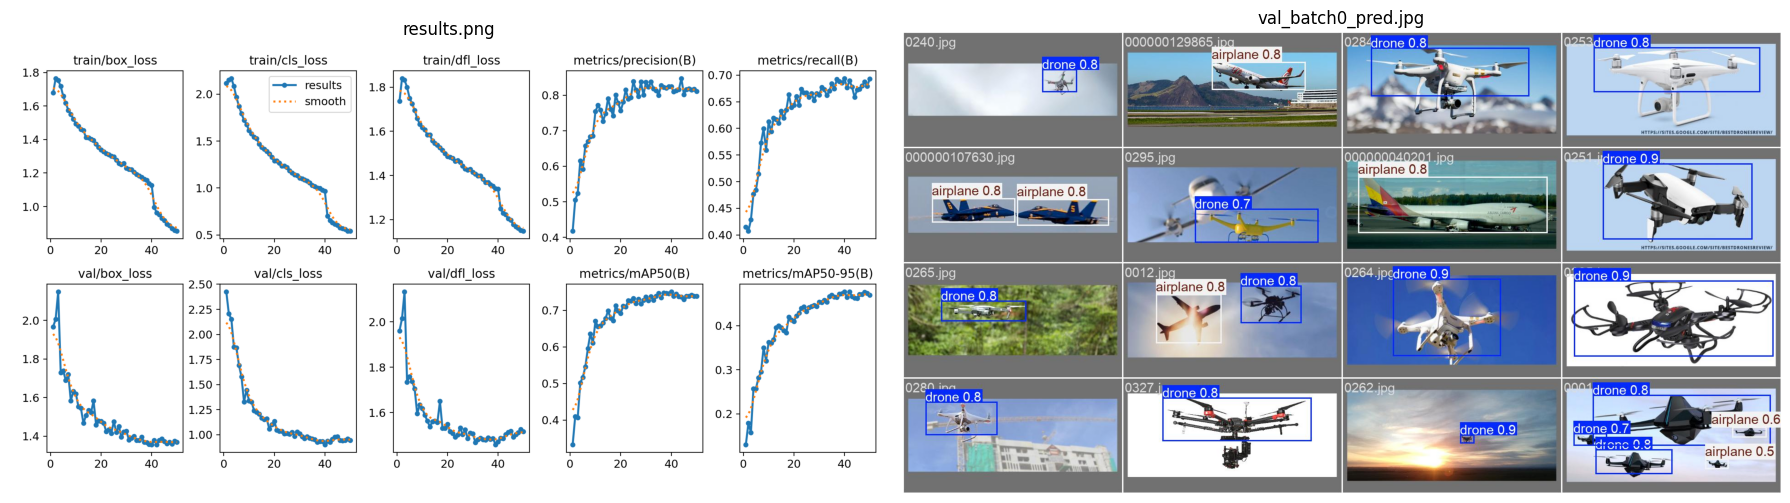

In [ ]:

# ─────────────────────────────────────────────
# 8. Visualise Training Curves
# ─────────────────────────────────────────────
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, fname in zip(axes, ["results.png", "val_batch0_pred.jpg"]):
    fpath = f"/content/runs/detect/endsem_train/{fname}"
    if os.path.exists(fpath):
        ax.imshow(Image.open(fpath))
        ax.axis("off")
        ax.set_title(fname)

plt.tight_layout()
plt.savefig("/content/training_overview.png", dpi=150)
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
files.download("/content/runs/detect/endsem_train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("/content/unified_dataset_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

# ─────────────────────────────────────────────
# 9. Inference Helper — with edge-case flags
# ─────────────────────────────────────────────
import cv2, numpy as np

def preprocess_low_light(image: np.ndarray) -> np.ndarray:
    """CLAHE enhancement for dark / night images before inference."""
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)


def preprocess_low_res(image: np.ndarray,
                        target_size: int = 640) -> np.ndarray:
    """Upscale small / blurry images with INTER_CUBIC for better inference."""
    h, w = image.shape[:2]
    if max(h, w) < target_size:
        scale = target_size / max(h, w)
        image = cv2.resize(image, (int(w * scale), int(h * scale)),
                           interpolation=cv2.INTER_CUBIC)
    return image


def run_inference(image_path: str,
                  conf: float = 0.25,
                  enhance_low_light: bool = False,
                  enhance_low_res: bool = False) -> str:
    """
    Run inference with optional preprocessing.
    Returns path to saved prediction image.
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(image_path)

    if enhance_low_light:
        img = preprocess_low_light(img)
    if enhance_low_res:
        img = preprocess_low_res(img)

    # Save preprocessed image temporarily
    tmp_path = "/content/tmp_inference_input.jpg"
    cv2.imwrite(tmp_path, img)

    results = trained_model.predict(
        source=tmp_path,
        conf=conf,
        iou=0.45,         # tighter NMS for crowded scenes
        max_det=50,
        save=True,
        project="/content/runs/detect",
        name="inference",
        exist_ok=True,
    )
    return results[0].save_dir



In [ ]:

# ── Quick test: upload a test image and run inference ─────────────────────────
files.upload()   # upload any test image (drone, bird, airplane, or night shot)

import glob
test_image = sorted(glob.glob("/content/*.jpg") + glob.glob("/content/*.jpeg") +
                    glob.glob("/content/*.png"))[-1]

print(f"\nRunning inference on: {test_image}")

save_dir = run_inference(
    test_image,
    conf=0.25,
    enhance_low_light=True,   # set False if the image is well-lit
    enhance_low_res=False,
)

# Show result
result_imgs = list(Path(save_dir).glob("*.*"))
if result_imgs:
    plt.figure(figsize=(10, 8))
    plt.imshow(Image.open(result_imgs[0]))
    plt.axis("off")
    plt.title("Prediction (drone=0 / bird=1 / airplane=2)")
    plt.show()


KeyboardInterrupt: 

In [ ]:

# ─────────────────────────────────────────────
# 10. Download best weights + result
# ─────────────────────────────────────────────
files.download("/content/runs/detect/endsem_train/weights/best.pt")
if result_imgs:
    files.download(str(result_imgs[0]))